In [1]:
import os, sys, json
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)
top_diseases = [normalise_str(d) for d in json.load(open('/media/lleger/LaCie/mit/disease_geometry/diseases.json'))['diseases']]
disease_indices_in_embedding_matrix = [tokenizer.token_to_id_map[d] for d in top_diseases]
disease_embeddings = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[disease_indices_in_embedding_matrix]
print(disease_embeddings.shape)

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading checkpoint-1500000
(50, 240)


## correlation matrix

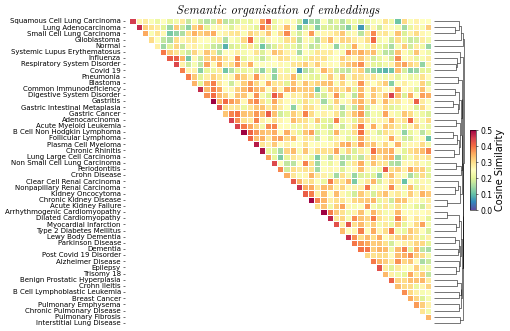

In [3]:
# Showing semantic organisation and phenomenology of disease landscape and foundation model geometry
from scipy.spatial.distance import pdist
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram

def plot_correlation_matrix(data, labels, palette='vlag', figsize=(12,8), dpi=200, fontsize=14,  save_path=None):
    
    x = cosine_similarity(data)
    pairwise_distance_matrix = pdist(data, metric="cosine")
    row_link = linkage(pairwise_distance_matrix, method="average", metric="cosine", optimal_ordering=True)
    order = leaves_list(row_link)
    corr = x[np.ix_(order, order)].copy()
    corr[np.tril_indices_from(corr, 0)] = np.nan

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(1, 3, width_ratios=(10, 0.75, 0.5), wspace=0)
    ax_heat = fig.add_subplot(gs[0, 0]); ax_dendro = fig.add_subplot(gs[0, 1],)
    vmin, vmax = .0, .5; center = 2*(vmin + vmax) / 4

    norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    labels = [' '.join([w.capitalize() for w in l[1:-1].split('_')]).
              replace('Right Ventricular ', '').replace('B Cell Acute', 'B Cell').replace('Chronic Obstructive', 'Chronic').
              replace('Variable ', '').replace('Renal Cell ', 'Renal ')
                for l in labels]
    sns.heatmap(corr, ax=ax_heat, cmap=palette, norm=norm, square=True, xticklabels=False, yticklabels=(np.asarray(labels)[order] if labels is not None else True),
                 mask=np.isnan(corr), cbar=False, lw=1, zorder=0)
    ax_heat.set_aspect('equal')
    ax_heat.set_facecolor('white')
    ax_heat.tick_params(axis='y', labelsize=fontsize-4)
    sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)

    pos_heat = ax_heat.get_position()
    pos_dendro = ax_dendro.get_position()
    ax_dendro.set_position([pos_heat.x1+0.005, pos_heat.y0, pos_dendro.width, pos_heat.height])
    dendrogram(row_link, orientation='right', color_threshold=0, above_threshold_color='k', no_labels=True, ax=ax_dendro)
    plt.setp(ax_dendro.collections, linewidth=0.75)
    for spine in ax_dendro.spines.values(): spine.set_visible(False)
    ax_dendro.axis('off')
    ax_dendro.invert_yaxis()
    ax_heat.tick_params(axis='y', direction='in',)

    cbar_ax = fig.add_axes([0.79, 0.4, 0.01, 0.2])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Cosine Similarity', fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize-3)
    ax_heat.set_title('Semantic organisation of embeddings', fontsize=fontsize+4, fontfamily="Latin Modern Roman", style='italic', y=1)
    if dpi > 300: plt.savefig('correlation_matrix.png', dpi=dpi, transparent=True,)
    #plt.tight_layout()
    plt.show()
    return order, corr, (fig, ax_heat, ax_dendro)

r = plot_correlation_matrix(data=disease_embeddings, labels=top_diseases, palette="Spectral_r", figsize=(12,8), dpi=50)

## population prediction

We want to show the performance of the model predicting phenotypes and gene expression. We want to show the growing heterogeneity of diseases as they deviate from normal

In [1]:
import numpy as np, pandas as pd

dataset_predictions = pd.read_pickle('/media/lleger/LaCie/mit/disease_geometry/dataset_predictions.pkl')
dataset_predictions.keys()

dict_keys(['phenotype_labels', 'phenotype_top_3_predictions', 'hidden_states', 'umap', 'pgmap'])

In [ ]:
import os, sys, time
sys.path.append('../../../')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc

from scipy.interpolate import CubicSpline
from polygene.model.model import load_trained_model

neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)

fontsize=14
palette = sns.color_palette("cubehelix", 10)

def compute_metrics(y_true, y_pred, k=3):
    metrics = []
    labels = np.unique(y_true)
    
    y_pred = np.array(y_pred)[:, :k]
    for label in labels:
        true_mask = (y_true == label)
        pred_mask = (y_pred[:, 0] == label)
        TP = np.sum(true_mask & pred_mask)
        FN = np.sum(true_mask & ~pred_mask)
        FP = np.sum(~true_mask & pred_mask)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        if k is not None:
            pred_mask_at_k = np.any(y_pred == label, axis=1)
            recall_at_k = np.sum(pred_mask_at_k & true_mask)/np.sum(true_mask)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        metrics.append([precision, recall, f1, recall_at_k]) if k is not None else metrics.append([precision, recall, f1])
    return pd.DataFrame(metrics, index=labels, columns=["precision", "recall", "f1", f"recall@{k}"])

def radial_spline(df: pd.DataFrame, figsize=(8,8), dpi=100):
    df.index = [' '.join(label[1:-1].split('_')).title() for label in df.index.tolist()]

    fig, ax = plt.subplots(subplot_kw={"projection":"polar"}, figsize=figsize, dpi=dpi)
    theta = np.linspace(0, 2*np.pi, df.shape[0], endpoint=False)
    rmin, rmax = 0, 1
    ax.set_ylim(rmin, 1.5*rmax)


    styles = { 
            'f1': {'color': palette[1], 'ls': '-', 'alpha':1, 'lw':4},
            'recall@3': {'color': palette[6], 'ls': '-', 'alpha':1, 'lw':2},
            'recall': {'color': palette[2], 'ls': '-', 'alpha':1, 'lw': 2},
            'precision': {'color': palette[3], 'ls': '--', 'alpha':1, 'lw': 2}
            }
    for idx, (angle, label) in enumerate(zip(theta, df.index.astype(str))):
        ax.plot([angle, angle], [rmin, 1.25*rmax], lw=1, ls=":", color="0.6")
        ax.text(angle, 1.1*rmax, f"{df.loc[label, 'f1']:.3f}", fontsize=fontsize, ha="right" if (np.cos(angle) < 0) else 'left', va="center") # score text
        ax.text(angle, rmax*1.35, label, ha="right" if (np.cos(angle) < 0) else 'left', va="center",fontsize=fontsize)
    
    for idx, (name, values) in enumerate(df.items()):
        cubic_spline = CubicSpline(np.r_[theta, theta[0]+2*np.pi], np.r_[values.values, values.values[0]], bc_type="periodic")
        phi = np.linspace(0, 2*np.pi, num=1000, endpoint=False)
        ax.plot(phi, cubic_spline(phi), lw=styles.get(name)['lw'], label=name.capitalize(), color=styles.get(name)['color'], ls=styles.get(name)['ls'], alpha=1)
        
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1), frameon=False, fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['polar'].set_visible(False)
    plt.tight_layout()
    if dpi >300:
        plt.savefig('disease_prediction_performance.png', dpi=600, transparent=False)
        plt.savefig('disease_prediction_performance.svg', dpi=600, transparent=True)
    plt.show()

#for phenotype in tokenizer.phenotypic_types:
for phenotype in ['disease']:
    labels = np.array(dataset_predictions['phenotype_labels'])[:, tokenizer.phenotypic_types.index(phenotype)]
    predictions = np.array(dataset_predictions['phenotype_top_3_predictions'])[:, tokenizer.phenotypic_types.index(phenotype)]
    metrics = compute_metrics(labels, predictions).sort_values('f1', ascending=False)
    metrics = metrics[metrics['f1'] > 0.8]
    metrics = metrics.sample(min(len(metrics), 25), random_state=3)
    radial_spline(metrics, dpi=50, figsize=(13, 8))

In [42]:
X_transf = np.load("X_transf.npy")

loading checkpoint-1500000


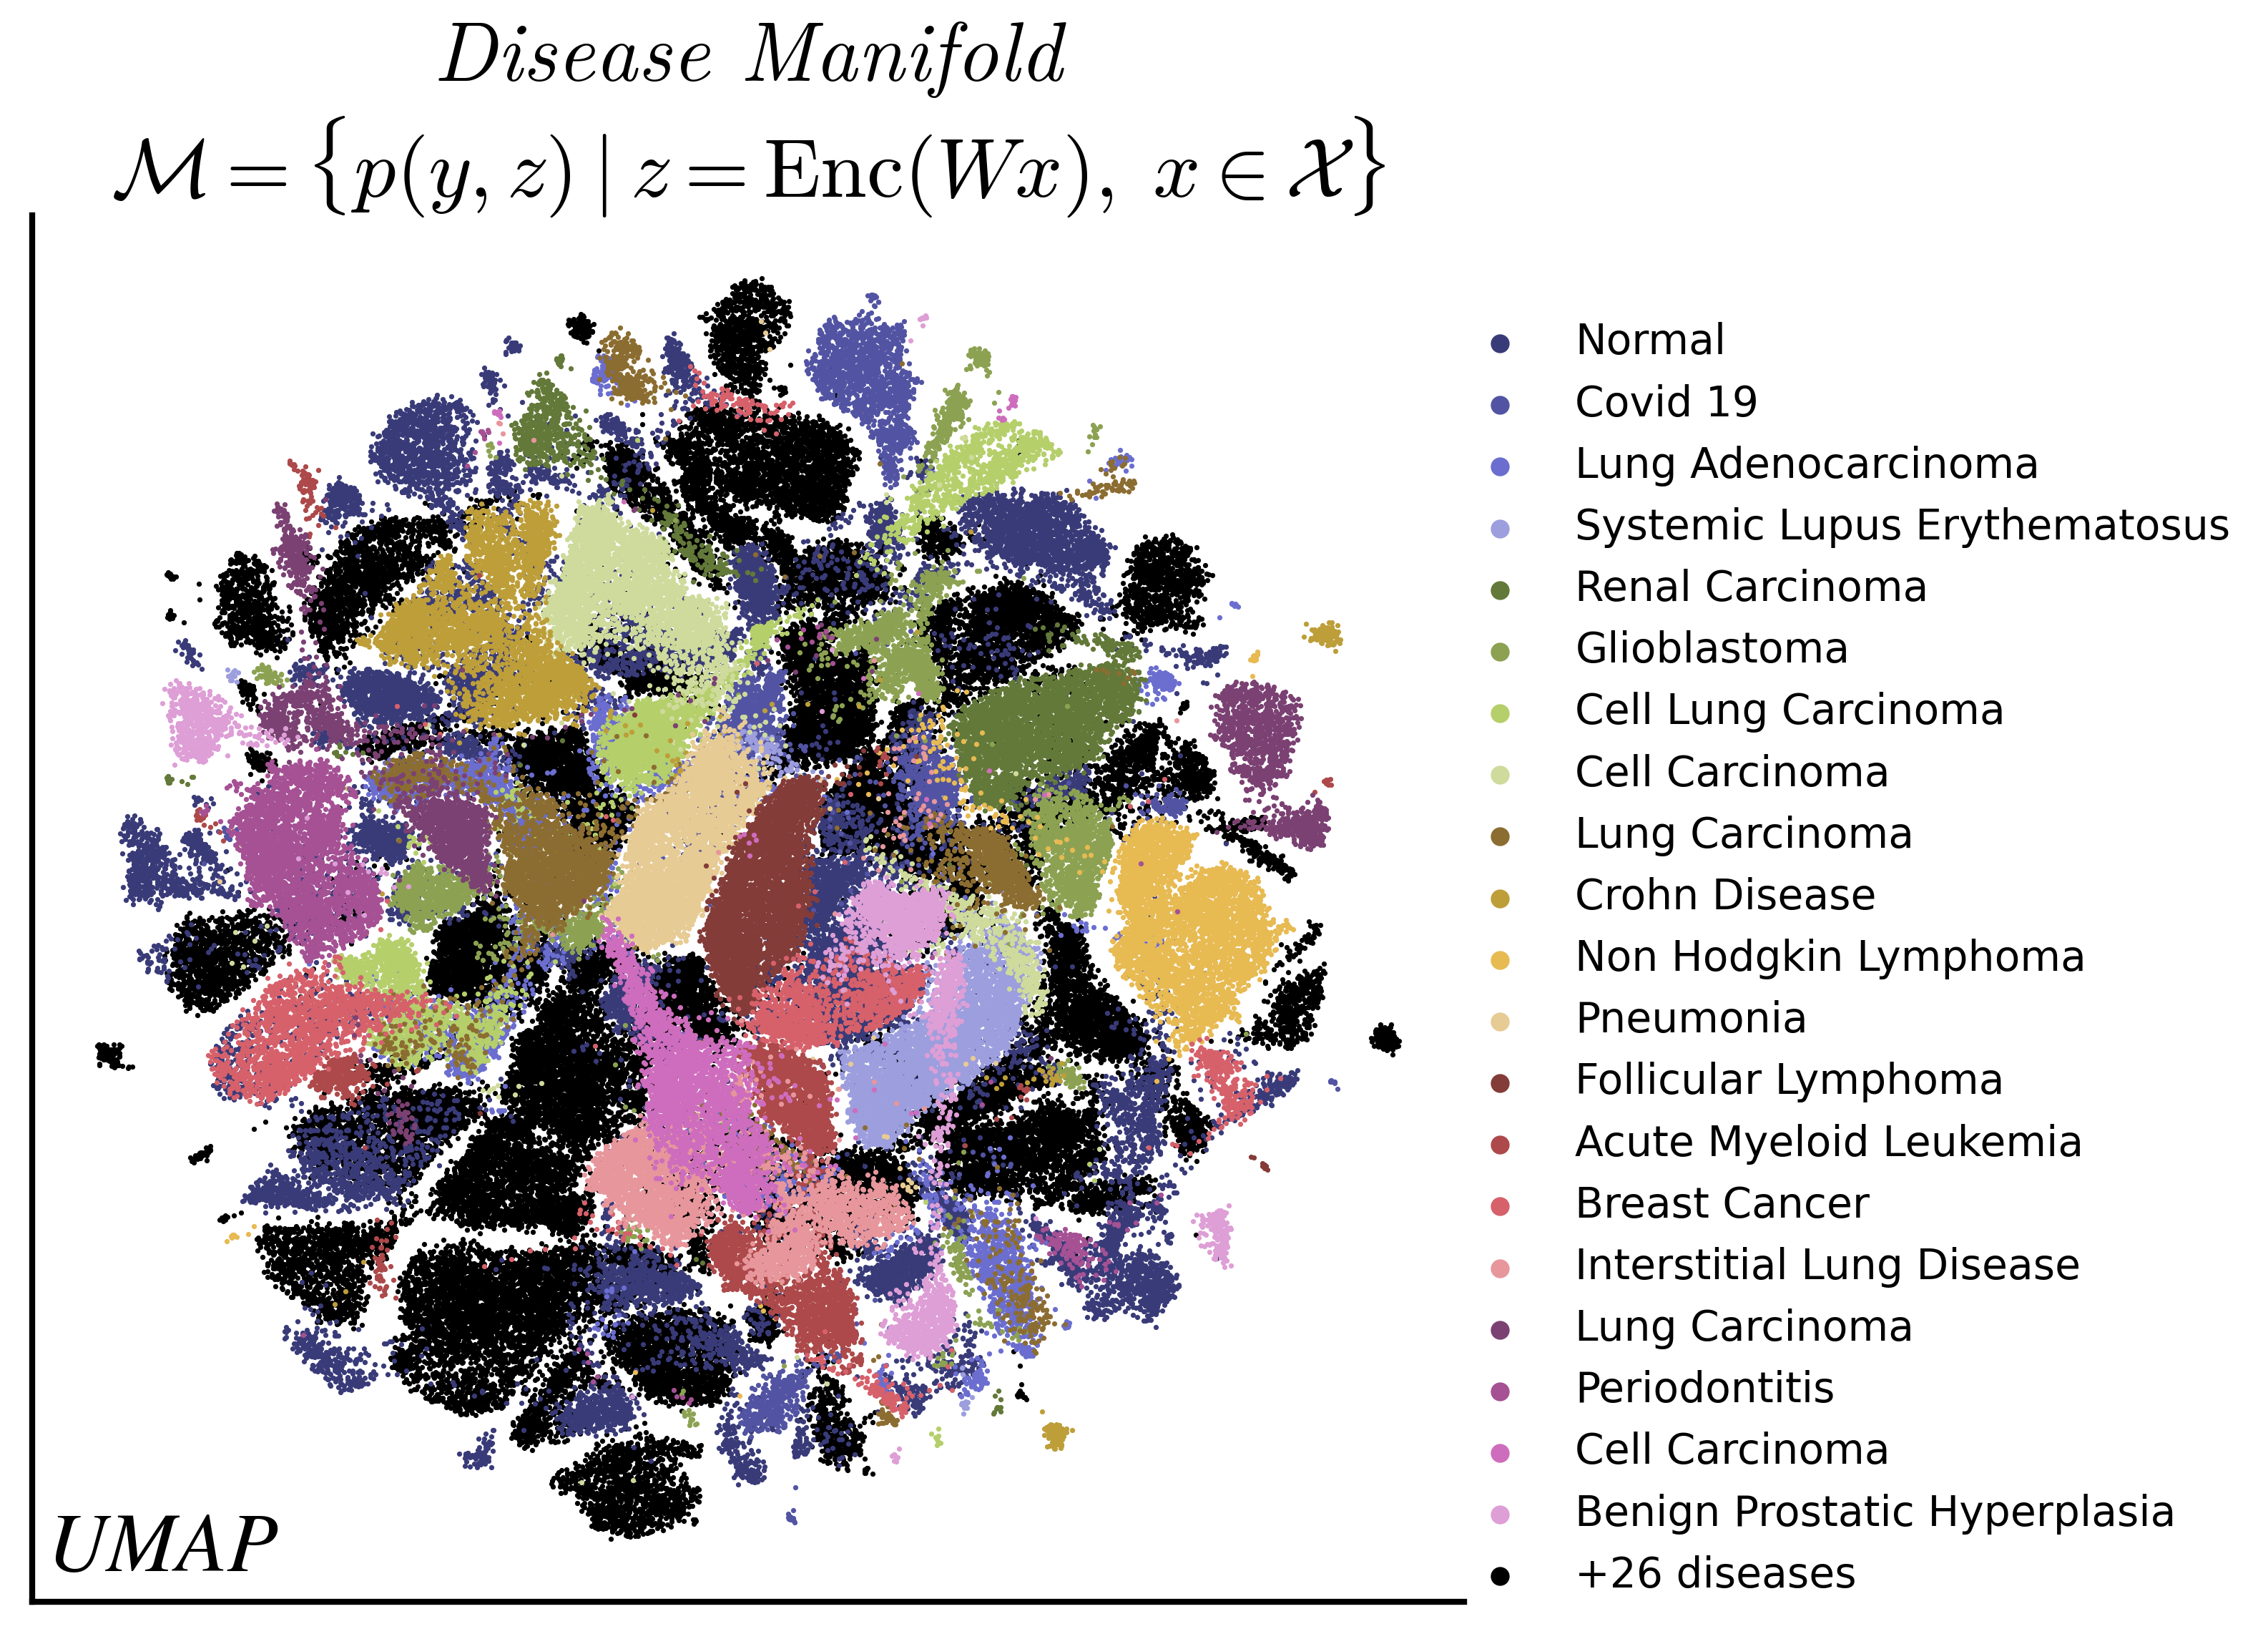

In [50]:
import os, sys
sys.path.append('../../../')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
from polygene.model.model import load_trained_model

neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)
fontsize = 14

plt.rcParams['mathtext.fontset'] = "cm"
#plt.rcParams['mathtext.fontset'] = "stix"
def plot_umap(data, labels, figsize=(12, 8), dpi=100, size=1, max_classes=20, palette_name="tab20", type_of_map="UMAP"):
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
        unique_classes = pd.Series(labels).value_counts().index.tolist()
        palette = sns.color_palette(palette_name, n_colors=max_classes)
        ax.set_aspect('equal')
        for idx, class_name in enumerate(unique_classes[:max_classes]):
            class_data = data[labels == class_name]
            readable_label = ' '.join(class_name[1:-1].split('_')).title()#[:15]
            if len(readable_label.split(' ')) > 3: readable_label = ' '.join(readable_label.split(' ')[2:])
        
            ax.scatter(class_data[:, 0], class_data[:, 1], color=palette[idx],
                        label=readable_label, s=size, lw=0, zorder=-0)
        
        if len(unique_classes) > max_classes:
            remaining_classes = unique_classes[max_classes:]
            remaining_classes_data = data[np.isin(labels, remaining_classes)]
            ax.scatter(remaining_classes_data[:, 0], remaining_classes_data[:, 1], color='k', alpha=1,
                        label=f'+{len(remaining_classes)} diseases', s=size, zorder=-100, lw=0)
        
        ax.spines[['top', 'right']].set_linewidth(0)
        ax.spines[['bottom', 'left']].set_linewidth(2)
        ax.set_xlabel(''); ax.set_ylabel('')
        ax.set_xticks([]); ax.set_yticks([])
        legend = ax.legend(frameon=False,  framealpha=0, fontsize=fontsize, bbox_to_anchor =(.97, 0.95), loc="upper left",)#, loc="lower right")
        for handle in legend.legendHandles: handle.set_sizes([40])
        

        ax.set_title(r"Disease Manifold" + "\n" + r"$\mathcal{M} = \{ p(y, z) \mid z = \mathrm{Enc}(Wx), \; x \in \mathcal{X} \}$"
                      if type_of_map != "UMAP" else "Transcriptome concentrations", fontfamily ='Latin Modern Roman', style="italic", fontsize = fontsize*2
                      , y=1)# fontdict={'fontsize': 28, 'fontfamily':"Latin Modern Roman", 'style': 'italic'}, y=1)
        #ax.text(x=0.01, y=0.01, s="UMAP", ha="left", va="bottom", transform=ax.transAxes, fontsize=fontsize*2,
        #        style="italic", fontfamily="Latin Modern Roman")
        #ax.set_title(r"Disease Manifold" + "\n" + r"$\mathcal{M} = \{ p(y \mid z) \mid z = \mathrm{Enc}(Wx) \; \forall z \in \mathcal{Z} \}$"
        #              if type_of_map != "UMAP" else "Transcriptome concentrations", fontfamily ='TeX Gyre Termes', style="italic", fontsize = fontsize*2
        #              , y=1)# fontdict={'fontsize': 28, 'fontfamily':"Latin Modern Roman", 'style': 'italic'}, y=1)
        ax.text(x=0.01, y=0.01, s="UMAP", ha="left", va="bottom", transform=ax.transAxes, fontsize=fontsize*2,
                style="italic", fontfamily="TeX Gyre Termes")
        #TeX Gyre Termes
        #TeX Gyre Termes
        plt.tight_layout()
        plt.savefig('pgmap.png', dpi=dpi)
        plt.show()
disease_labels = np.array(dataset_predictions['phenotype_labels'])[:, tokenizer.phenotypic_types.index('disease')]
#plot_umap(data=dataset_predictions['umap'], labels=disease_labels, figsize=(10, 8), dpi=200, size=1, palette_name="tab20b", max_classes=20, type_of_map="UMAP")
#plot_umap(data=dataset_predictions['pgmap'], labels=disease_labels, figsize=(12, 8), dpi=300, size=2, palette_name="tab20b", max_classes=20, type_of_map="pgMAP")
plot_umap(data=X_transf, labels=disease_labels, figsize=(12, 8), dpi=300, size=3, palette_name="tab20b", max_classes=20, type_of_map="pgMAP")

In [77]:
disease_labels = np.array(dataset_predictions['phenotype_labels'])[:, tokenizer.phenotypic_types.index('disease')]
Z = np.concatenate(dataset_predictions['hidden_states'])

diseases = np.unique(disease_labels)
normal_centroid = Z[disease_labels == "[normal]"].mean(axis=0)
#normal_centroid /= np.linalg.norm(normal_centroid)
standard_deviations = []
centroids = []
for disease in diseases:
    if disease =="[normal]": continue
    standard_deviations.append(Z[disease_labels == disease].std(axis=0).mean())
    average = Z[disease_labels == disease].mean(axis=0)
    #average /= np.linalg.norm(average)
    centroids.append(average)

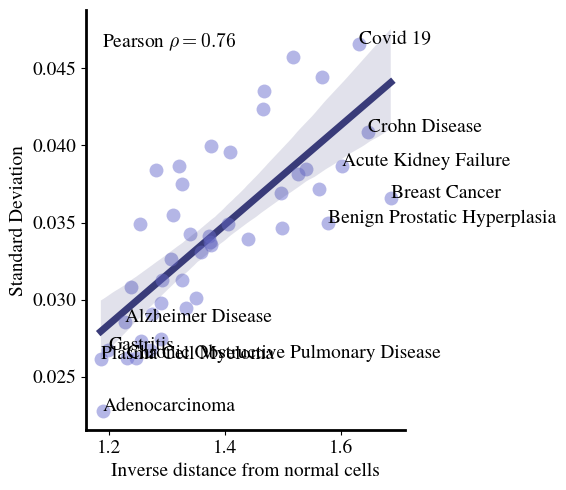

In [115]:
from scipy.stats import linregress

cosine = lambda x, y: np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
cosine_similarity_with_normal = [1/np.linalg.norm(x - normal_centroid) for x in centroids]

slope, intercept, r_value, p_value, std_error = linregress(cosine_similarity_with_normal, standard_deviations)

plt.rcParams['font.family'] = "Tex Gyre Termes"
fontsize=14
dpi=100
plt.rcParams['mathtext.fontset'] = "cm"
palette = sns.color_palette("tab20b")
fig,ax = plt.subplots(figsize=(5.5,5),dpi=dpi)
#ax.set_aspect('equal', adjustable='datalim')

sns.regplot(
    x=cosine_similarity_with_normal,
    y=standard_deviations,
    ci=95,
    n_boot=1000,
    scatter_kws={"s": 100, "alpha": 0.5, "color": palette[2], "lw":0},
    line_kws={"color": palette[0], "lw": 5, "zorder": -10}, ax=ax
)
diseases = np.unique(disease_labels)
diseases = diseases[diseases != '[normal]']
cosine_array = np.array(cosine_similarity_with_normal)
std_array = np.array(standard_deviations)

high_high = np.argsort(-(cosine_array + std_array))[:5]
low_low = np.argsort(cosine_array + std_array)[:5]

for i in np.concatenate([high_high, low_low]):
    label = ' '.join(w.capitalize() for w in diseases[i][1:-1].split('_'))
    plt.annotate(label, (cosine_array[i], std_array[i]), fontsize=fontsize, zorder=20)
plt.text(0.05, 0.95,fr"Pearson $\rho= {np.corrcoef(cosine_similarity_with_normal, standard_deviations)[1, 0]:.2f}$",
    transform=plt.gca().transAxes, ha="left", va="top", fontsize=fontsize, zorder=100, fontfamily="Tex Gyre Termes")

ax.tick_params('both', labelsize=fontsize)
ax.set_xlabel("Inverse distance from normal cells", fontsize=fontsize)
ax.set_ylabel("Standard Deviation", fontsize=fontsize)

ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)

plt.tight_layout()
plt.show()

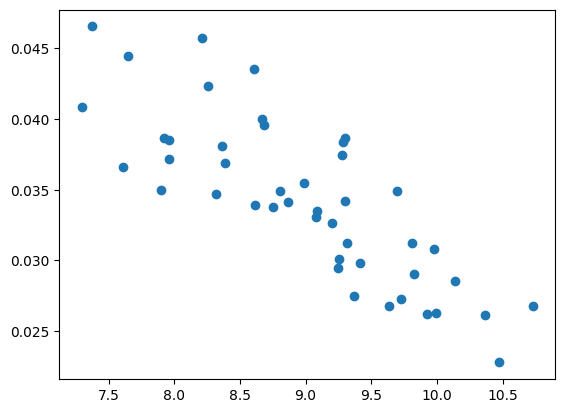

In [51]:
import seaborn as sns, matplotlib.pyplot as plt, numpy as np

cosine = lambda x,y : np.dot(x,y)/(np.linalg.norm(x)*np.linalg.norm(y))
cosine_similarity_with_normal = [np.abs(x - normal_centroid).sum() for x in centroids]
plt.scatter(cosine_similarity_with_normal, standard_deviations)

## integral paths of lung cancer

to illustrate what we mean by integral paths or the physical paths the paths the maximise the probability toward disease lets visualize them for lung cancer

In [ ]:


import os, sys
sys.path.append('../../../')
import numpy as np, pandas as pd, scanpy as sc
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)

dataset_path = "/media/lleger/LaCie/mit/disease_geometry/cxg_lung_dataset/"
lung_cancers = ["lung adenocarcinoma", "lung large cell carcinoma", "squamous cell lung carcinoma", "small cell lung carcinoma", "normal"]
cells = [sc.read_h5ad(dataset_path + cancer + "_shard.h5ad") for cancer in lung_cancers]
cells = sc.concat([shard[:500] for shard in cells]) #['type II pneumocyte', 'malignant cell', 'epithelial cell', 'native cell']

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell

cxg_lung_dataset_prediction = {}
save_path = dataset_path + "../cxg_lung_dataset_prediction.pkl"
mask_id = tokenizer.token_to_id_map[tokenizer.mask_token]
if os.path.exists(save_path) and False:
    cxg_lung_dataset_prediction = pd.read_pickle(save_path)
else:
    for i, cell in enumerate(tqdm(cells)):
        cell_dict, labels = prepare_cell(cell, tokenizer)
        cell_dict['input_ids'][1: 1+len(tokenizer.phenotypic_types)] = mask_id
        output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
        cxg_lung_dataset_prediction.setdefault('hidden_states', []).append(  output.hidden_states[:, 1 + tokenizer.phenotypic_types.index('disease')].detach().cpu().numpy() )
        cxg_lung_dataset_prediction.setdefault('labels', []).append(labels[1: 1+len(tokenizer.phenotypic_types)])
    pd.to_pickle(cxg_lung_dataset_prediction, save_path)

In [ ]:
import sys
sys.path.append('../../../')
from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
import os, sys, torch, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str

disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature
W = model.prediction_head[-1].weight
tau = model.temperature

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
def riemannian_metric(z, W, tau):
    logits = (W @ z) / tau
    probability_distribution = softmax(logits, dim=0)
    fisher_information_logits = torch.diag(probability_distribution) - probability_distribution[:, None] * probability_distribution[None, :]
    G = (W / tau).T @ fisher_information_logits @ (W / tau)
    return G

gradients_per_grid_side, border, whiten_pca = 10, 1, True

df = pd.DataFrame({"embeddings": np.concatenate(cxg_lung_dataset_prediction['hidden_states']).tolist(), "disease": cells.obs['disease']})
pca = PCA(n_components=2, whiten=whiten_pca, svd_solver="full", random_state=3)

df[['x','y']] = pca.fit_transform(np.array(df['embeddings'].tolist())).tolist()
explained_var = pca.explained_variance_ratio_

# sample a grid of points in the linear slice of the manifold
x_min, x_max = df['x'].min()-border, df['x'].max()+border
y_min, y_max = df['y'].min()-border, df['y'].max()+border
grid_x, grid_y = np.linspace(x_min, x_max, gradients_per_grid_side), np.linspace(y_min, y_max, gradients_per_grid_side)
X, Y = np.meshgrid(grid_x, grid_y)

grid_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
grid_embeddings = pca.inverse_transform(grid_coordinates)

vector_fields = {"meshgrid_coordinates": (X, Y)}
for z in tqdm(grid_embeddings):
    z = torch.tensor(z / np.linalg.norm(z, axis=-1), device=model.device, dtype=torch.float32, requires_grad=True)
    metric = riemannian_metric(z, W, tau)#
    inverse_metric = torch.linalg.inv(metric).detach().cpu().numpy()
    probability_distribution = softmax(decoder(z), dim=0)
    for disease in lung_cancers:
        probability_of_disease  = probability_distribution[tokenizer.token_to_id_map[normalise_str(disease)]]
        probability_of_disease.backward(retain_graph=True)
        gradient = z.grad.detach().cpu().numpy()
        vector_fields.setdefault(f"{disease}_gradients", []).append(gradient)
        vector_fields.setdefault(f"{disease}_riemannian", []).append( gradient @ inverse_metric)
        z.grad.zero_()

for key in vector_fields:
    if "meshgrid" in key: continue
    vector_fields[key] = pca.transform(np.array(vector_fields[key]))

In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
import matplotlib.pyplot as plt, seaborn as sns
arrow_scale, arrow_width, arrow_color = 5, 0.004, "k"

disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers if disease != 'normal']]
disease_representations_pca = pca.transform(disease_representations)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fontsize, dpi=14, 300
plot_border = 1.15*border
for disease in lung_cancers:
        print(disease)
        X, Y = vector_fields['meshgrid_coordinates']
        gradients = vector_fields[f'{disease}_riemannian'].reshape(X.shape[0], X.shape[1], -1)
        gradients = vector_fields[f'{disease}_gradients'].reshape(X.shape[0], X.shape[1], -1)
        fig, ax = plt.subplots(1,1, figsize=(9, 6), dpi=dpi)
        
        width = 2*np.log(np.linalg.norm(gradients, axis=-1)) / np.log(np.linalg.norm(gradients, axis=-1)).max()
        gradients_normalised = gradients / np.linalg.norm(gradients, axis=-1, keepdims=True)
        ax.streamplot(X, Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], broken_streamlines=True,
                       integration_direction="both", density=2, color=(0, 0, 0, 0.9), linewidth=1)#linewidth=width)
        # density=[0.5, 1])
        ax.set_xticklabels([]);ax.set_yticklabels([])
        ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
        ax.set_xlim(df['x'].min()-plot_border,df['x'].max()+plot_border);ax.set_ylim(df['y'].min()-plot_border,df['y'].max()+plot_border)
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize)
        
        palette = sns.color_palette('Paired',n_colors=20)
        sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=palette,s=10,alpha=0.8,ax=ax,linewidth=0,zorder=1)
        
        #for idx, cancer_name in enumerate([cancer for cancer in lung_cancers if cancer != "normal"]):
        #    plt.scatter(disease_representations_pca[idx, 0], disease_representations_pca[idx, 1], s=50,
        #                 label=cancer_name + ' fixed point', color=palette[idx], marker="X", lw=1, edgecolor="k",)
        
        arrow_gray = FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color=arrow_color,linewidth=1)
        def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
            return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor()
                                        if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)
        
        handles, legend_labels_= ax.get_legend_handles_labels()
        handles.append(arrow_gray)
        legend_labels_.append(f"Integral paths \n$\partial_i p ( {disease.replace('lung ', '').replace(' carcinoma', '')} | z)$")
        legend = ax.legend(handles, [label.replace('lung ', '').replace(' carcinoma', '').replace('normal', 'Healthy Pneumocytes').title() if not "path" in label else label for label in legend_labels_], frameon=True,
                            bbox_to_anchor=(1,1),
                        borderaxespad=0.5, edgecolor='none', framealpha=0.8,# loc="upper right",
                        fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)}, title="Lung Cancers", title_fontsize=fontsize)
        for h in legend.legendHandles: 
               
               if hasattr(h,"set_markersize"): h.set_markersize(5); h.set_alpha(1)
        plt.tight_layout()
        plt.show()
        break

        

In [ ]:
disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

In [ ]:
dataset_path = "/media/lleger/LaCie/mit/disease_geometry/dataset/"

import os, sys, json
sys.path.append('../../../')

from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=12)

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell
import scanpy as sc, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str

hidden_states = []
if os.path.exists("integral_paths_embeddings.npy"):
    hidden_states = np.load("integral_paths_embeddings.npy")
    labels = []
    for i, state in enumerate(tqdm(hidden_states)):
        state = torch.tensor(state, device=model.device)
        labels.append(tokenizer.flattened_tokens[model.prediction_head(state).argmax()])

diseases = pd.Series(labels).value_counts().index.tolist()[:5]
hidden_states = hidden_states[pd.Series(labels).isin(diseases)]
labels = np.array(labels)[pd.Series(labels).isin(diseases)].tolist()
disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

In [ ]:
import sys
sys.path.append('../../../')
from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
import os, sys, torch, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str

#disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature
W = model.prediction_head[-1].weight
tau = model.temperature

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
def riemannian_metric(z, W, tau):
    logits = (W @ z) / tau
    probability_distribution = softmax(logits, dim=0)
    fisher_information_logits = torch.diag(probability_distribution) - probability_distribution[:, None] * probability_distribution[None, :]
    G = (W / tau).T @ fisher_information_logits @ (W / tau)
    return G

gradients_per_grid_side, border, whiten_pca = 10, 1, True

df = pd.DataFrame({"embeddings": np.concatenate(cxg_lung_dataset_prediction['hidden_states']).tolist(), "disease": cells.obs['disease']})
pca = PCA(n_components=2, whiten=whiten_pca, svd_solver="full", random_state=3)

df[['x','y']] = pca.fit_transform(np.array(df['embeddings'].tolist())).tolist()
explained_var = pca.explained_variance_ratio_

# sample a grid of points in the linear slice of the manifold
x_min, x_max = df['x'].min()-border, df['x'].max()+border
y_min, y_max = df['y'].min()-border, df['y'].max()+border
grid_x, grid_y = np.linspace(x_min, x_max, gradients_per_grid_side), np.linspace(y_min, y_max, gradients_per_grid_side)
X, Y = np.meshgrid(grid_x, grid_y)

grid_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
grid_embeddings = pca.inverse_transform(grid_coordinates)

vector_fields = {"meshgrid_coordinates": (X, Y)}
for z in tqdm(grid_embeddings):
    z = torch.tensor(z / np.linalg.norm(z, axis=-1), device=model.device, dtype=torch.float32, requires_grad=True)
    metric = riemannian_metric(z, W, tau)#
    inverse_metric = torch.linalg.inv(metric).detach().cpu().numpy()
    probability_distribution = softmax(decoder(z), dim=0)
    for disease in lung_cancers:
        probability_of_disease  = probability_distribution[tokenizer.token_to_id_map[normalise_str(disease)]]
        probability_of_disease.backward(retain_graph=True)
        gradient = z.grad.detach().cpu().numpy()
        vector_fields.setdefault(f"{disease}_gradients", []).append(gradient)
        vector_fields.setdefault(f"{disease}_riemannian", []).append( gradient @ inverse_metric)
        z.grad.zero_()

for key in vector_fields:
    if "meshgrid" in key: continue
    vector_fields[key] = pca.transform(np.array(vector_fields[key]))


# Shared integral paths

In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
import matplotlib.pyplot as plt, seaborn as sns
arrow_scale, arrow_width, arrow_color = 5, 0.004, "k"

disease_representations_pca = pca.transform(disease_representations)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fontsize, dpi=14, 300
plot_border = 1.15*border
for disease in lung_cancers:
        print(disease)
        X, Y = vector_fields['meshgrid_coordinates']
        gradients = vector_fields[f'{disease}_gradients'].reshape(X.shape[0], X.shape[1], -1)
        gradients = vector_fields[f'{disease}_riemannian'].reshape(X.shape[0], X.shape[1], -1)
        fig, ax = plt.subplots(1,1, figsize=(9, 6), dpi=dpi)
        gradients_normalised = gradients #/ np.linalg.norm(gradients, axis=-1, keepdims=True)
        #ax.quiver(X,Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], color=arrow_color,
        #        alpha=.6,scale_units='xy',scale=arrow_scale,width=arrow_width,headwidth=3,headlength=5,headaxislength=4,zorder=5)
        width = 2*np.log(np.linalg.norm(gradients, axis=-1)) / np.log(np.linalg.norm(gradients, axis=-1)).max()
        ax.streamplot(X, Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], broken_streamlines=True,
                       integration_direction="both", density=2, color=(0, 0, 0, 0.9), linewidth=width)
        # density=[0.5, 1])
        ax.set_xticklabels([]);ax.set_yticklabels([])
        ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
        ax.set_xlim(df['x'].min()-plot_border,df['x'].max()+plot_border);ax.set_ylim(df['y'].min()-plot_border,df['y'].max()+plot_border)
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize)
        
        sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=10,alpha=0.8,ax=ax,linewidth=0,zorder=1)
        
        plt.scatter(disease_representations_pca[:, 0], disease_representations_pca[:, 1], s=20, label='Fixed points', color="k", marker="x", lw=1)
        
        arrow_gray = FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color=arrow_color,linewidth=1)
        def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
            return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor()
                                        if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)
        
        handles, legend_labels_= ax.get_legend_handles_labels()
        handles.append(arrow_gray)
        legend_labels_.append(f"Integral paths \n$\partial_i p ( {disease.replace('lung ', '').replace(' carcinoma', '')} | z)$")
        #legend_labels_.append(f"Gradient field \n$\partial_i p ( {disease.replace('lung ', '').replace(' carcinoma', '')} | z)$")
        legend = ax.legend(handles, [label.replace('lung ', '').replace(' carcinoma', '').replace('normal', 'Healthy Pneumocytes').title() if not "path" in label else label for label in legend_labels_], frameon=True,
                            bbox_to_anchor=(1,1),
                        borderaxespad=0.5, edgecolor='none', framealpha=0.8,# loc="upper right",
                        fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)}, title="Lung Cancers", title_fontsize=fontsize)
        for h in legend.legendHandles: 
               
               if hasattr(h,"set_markersize"): h.set_markersize(5); h.set_alpha(1)
        plt.tight_layout()
        #plt.savefig(f'{disease}_integral_paths.png', dpi=300)
        plt.show()
        #break

        

In [ ]:
dataset_path = "/media/lleger/LaCie/mit/disease_geometry/dataset/"

import os, sys, json
sys.path.append('../../../')

from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=12)

import scanpy as sc, numpy as np, pandas as pd
lung_cancers = ["lung adenocarcinoma", "lung large cell carcinoma", "squamous cell lung carcinoma", "small cell lung carcinoma"]
healthy_cells = sc.read_h5ad(dataset_path + "healthy_lung_cells.h5ad")[:1000]
cancer_cells = [sc.read_h5ad(dataset_path + cancer.replace(' ', '_') + "_shard0.h5ad")[:1000] for cancer in lung_cancers]
cells = sc.concat([healthy_cells] + cancer_cells)

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell
from polygene.data_utils.tokenization import normalise_str

hidden_states = []
if os.path.exists("integral_paths_embeddings.npy"):
    hidden_states = np.load("integral_paths_embeddings.npy")
else:
    for i, cell in enumerate(tqdm(cells)):
        cell_dict, labels = prepare_cell(cell, tokenizer)
        cell_dict['input_ids'][1: 1+len(tokenizer.phenotypic_types)] = tokenizer.token_to_id_map[tokenizer.mask_token]
        output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
        latent_embedding = output.hidden_states[:, 1 + tokenizer.phenotypic_types.index('disease')].detach().cpu().numpy()
        hidden_states.append( latent_embedding )
    hidden_states = np.concatenate(hidden_states)
    np.save("integral_paths_embeddings.npy", arr=hidden_states)

disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

In [ ]:
import sys
sys.path.append('../../../')
import alphashape
from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
from shapely.geometry import LineString
from scipy.linalg import orthogonal_procrustes
import os, sys, torch, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str

disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature
log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
W = model.prediction_head[-1].weight
tau = model.temperature

def riemannian_metric(z, W, tau):
    logits = (W @ z) / tau
    probability_distribution = softmax(logits, dim=0)
    fisher_information_logits = torch.diag(probability_distribution) - probability_distribution[:, None] * probability_distribution[None, :]
    G = (W / tau).T @ fisher_information_logits @ (W / tau)
    return G

gradients_per_grid_side, border, whiten_pca = 10, 2, True

df = pd.DataFrame({"embeddings": hidden_states.tolist(), "disease": labels})
#df = df[df['disease'].isin(["small cell lung carcinoma", "normal"])]
pca = PCA(n_components=2, whiten=whiten_pca, svd_solver="full")

df[['x','y']] = pca.fit_transform(np.array(df['embeddings'].tolist())).tolist()
explained_var = pca.explained_variance_ratio_.copy()

# sample a grid of points in the linear slice of the manifold
x_min, x_max = df['x'].min()-border, df['x'].max()+border
y_min, y_max = df['y'].min()-border, df['y'].max()+border
grid_x, grid_y = np.linspace(x_min, x_max, gradients_per_grid_side), np.linspace(y_min, y_max, gradients_per_grid_side)
X, Y = np.meshgrid(grid_x, grid_y)

grid_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
grid_embeddings = pca.inverse_transform(grid_coordinates)

vector_fields = {"meshgrid_coordinates": (X, Y)}
for z in tqdm(grid_embeddings):
    z = torch.tensor(z, device=model.device, dtype=torch.float32, requires_grad=True)
    metric = riemannian_metric(z, W, tau)#
    inverse_metric = torch.linalg.inv(metric).detach().cpu().numpy()
    probability_distribution = softmax(decoder(z), dim=0)
    for disease in lung_cancers:
        probability_of_disease  = probability_distribution[tokenizer.token_to_id_map[normalise_str(disease)]]
        probability_of_disease.backward(retain_graph=True)
        gradient = z.grad.detach().cpu().numpy()
        vector_fields.setdefault(f"{disease}_gradients", []).append(gradient)
        vector_fields.setdefault(f"{disease}_riemannian", []).append( gradient @ inverse_metric)
        z.grad.zero_()

for key in vector_fields:
    if not "grad" in key and not "riem" in key: continue
    vector_fields[key] = pca.transform(np.array(vector_fields[key]))

In [ ]:
df = pd.DataFrame({"embeddings": hidden_states.tolist(), "disease": cells.obs['disease']})
df = df[df["disease"] == "normal"]

decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature

import torch

max_steps_integral_paths, step_size = 400, 0.5
integral_paths = {}
disease_transition = {}

for embedding in tqdm(df['embeddings'].sample(n=500, random_state=3), disable=False):
    z = torch.tensor(embedding, device=model.device, dtype=torch.float32)
    for disease_index, disease in enumerate(lung_cancers):
        gradient_flow_path = [torch.clone(z).requires_grad_(True)]
        disease_representation = torch.tensor(disease_representations[disease_index], device=model.device)
        disease_vocab_index = tokenizer.token_to_id_map[normalise_str(disease)]
        pbar = tqdm(range(max_steps_integral_paths), disable=True)
        transition = None
        probabilities = []
        for step in pbar:
            #pbar.set_description(f'error: {torch.norm(gradient_flow_path[-1] - disease_representation).item()}')
            gradient_flow_path[-1].grad = None
            probability = torch.nn.functional.softmax( decoder(gradient_flow_path[-1]), dim=-1)
            probability[disease_vocab_index].backward(retain_graph=True)
            gradient = gradient_flow_path[-1].grad.detach()
            #gradient = gradient / gradient.norm()
            next_z = gradient_flow_path[-1] + step_size*gradient
            next_z = next_z / next_z.norm()
            gradient_flow_path.append( next_z.detach().requires_grad_(True) )
            probabilities.append(probability)
        
        is_target = (torch.stack(probabilities).argmax(dim=-1) == disease_vocab_index)
        switch_to_target = (~is_target[:-1] & is_target[1:]).nonzero(as_tuple=True)[0]
        transition = switch_to_target[0].item() + 1 if len(switch_to_target) > 0 else max_steps_integral_paths

        integral_paths.setdefault(disease, []).append(torch.stack(gradient_flow_path).detach().cpu().numpy())
        disease_transition.setdefault(disease, []).append(transition)
#pd.to_pickle(integral_paths, )

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, pandas as pd

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
fontsize=14

integral_paths = pd.read_pickle("integral_paths.pkl")
disease_transition = pd.read_pickle('disease_transition.pkl')
def cosine_similarity(a, b):
    return np.sum(a * b, axis=-1) / (np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1) + 1e-8)

velocities = {disease: np.diff(np.stack(paths), axis=1) for disease, paths in integral_paths.items()}

fig, ax = plt.subplots(figsize=(8, 4), dpi=500)

palette = sns.color_palette('cubehelix', n_colors=len(lung_cancers) * (len(lung_cancers) - 1) // 2)
color_idx = 0

for i, disease_a in enumerate(lung_cancers):
    for disease_b in lung_cancers[i+1:]:
        similarity = cosine_similarity(velocities[disease_a], velocities[disease_b]).mean(axis=0)
        label_a = disease_a.replace('lung ', '').replace(' carcinoma', '').title()
        label_b = disease_b.replace('lung ', '').replace(' carcinoma', '').title()
        ax.plot(similarity, label=f"{label_a} \& {label_b}", color=palette[color_idx], linewidth=1.5, alpha=0.85)
        color_idx += 1

curve_grays = sns.cubehelix_palette(n_colors=4, start=0, rot=0, light=0.4, dark=0.7)
palette = sns.color_palette('Greys_r', n_colors=len(lung_cancers))

disease_colors = {disease: palette[i] for i, disease in enumerate(["lung adenocarcinoma", "squamous cell lung carcinoma", "lung large cell carcinoma", "small cell lung carcinoma"])}

for disease in ["lung adenocarcinoma", "squamous cell lung carcinoma", "lung large cell carcinoma", "small cell lung carcinoma"]:
    mean_step = np.mean(disease_transition[disease])
    label = disease.replace('lung ', '').replace(' carcinoma', '').replace('normal', 'Healthy').title()
    ax.axvline(mean_step, color=disease_colors[disease], linestyle='--', linewidth=2, alpha=1, label=f'{label} transition', zorder=-1)

ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Integration Step', fontsize=fontsize)
ax.set_ylabel('Cosine similarity of gradients', fontsize=fontsize)
ax.set_title('Integral path similarity over time', fontsize=fontsize)
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.tick_params('both', labelsize=fontsize)
#ax.legend(bbox_to_anchor=(1, 1), fontsize=10, frameon=True, edgecolor='none', framealpha=0.8, title='Similarity between', title_fontsize=12)
handles, labels = ax.get_legend_handles_labels()
n_sim = len(lung_cancers) * (len(lung_cancers) - 1) // 2  # number of similarity curves

leg1 =ax.legend(handles[n_sim:], labels[n_sim:], bbox_to_anchor=(1, 0.45),
          fontsize=10, frameon=True, edgecolor='none', framealpha=0.8,
          title='Phenotype transitions', title_fontsize=12)
ax.add_artist(leg1)
ax.legend(handles[:n_sim], labels[:n_sim], bbox_to_anchor=(1, 1),
                 fontsize=10, frameon=True, edgecolor='none', framealpha=0.8,
                 title='Path similarity', title_fontsize=12)
plt.tight_layout()

plt.savefig('shared_integral_paths.png', dpi=500)
plt.show()

In [ ]:
model.prediction_head

In [ ]:
W = model.prediction_head[-1].weight
W.shape

In [ ]:
import sys
sys.path.append('../../../')
import alphashape
from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
from shapely.geometry import LineString
from scipy.linalg import orthogonal_procrustes
import os, sys, torch, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str

disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature
log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
W = model.prediction_head[-1].weight
tau = model.temperature

def riemannian_metric(z, W, tau):
    logits = (W @ z) / tau
    probability_distribution = softmax(logits, dim=0)
    fisher_information_logits = torch.diag(probability_distribution) - probability_distribution[:, None] * probability_distribution[None, :]
    G = (W / tau).T @ fisher_information_logits @ (W / tau)
    return G

gradients_per_grid_side, border, whiten_pca = 10, 2, True

df = pd.DataFrame({"embeddings": hidden_states.tolist(), "disease": cells.obs['disease']})
#df = df[df['disease'].isin(["small cell lung carcinoma", "normal"])]
pca = PCA(n_components=2, whiten=whiten_pca, svd_solver="full")

df[['x','y']] = pca.fit_transform(np.array(df['embeddings'].tolist())).tolist()
explained_var = pca.explained_variance_ratio_.copy()

# sample a grid of points in the linear slice of the manifold
x_min, x_max = df['x'].min()-border, df['x'].max()+border
y_min, y_max = df['y'].min()-border, df['y'].max()+border
grid_x, grid_y = np.linspace(x_min, x_max, gradients_per_grid_side), np.linspace(y_min, y_max, gradients_per_grid_side)
X, Y = np.meshgrid(grid_x, grid_y)

grid_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
grid_embeddings = pca.inverse_transform(grid_coordinates)

vector_fields = {"meshgrid_coordinates": (X, Y)}
for z in tqdm(grid_embeddings):
    z = torch.tensor(z, device=model.device, dtype=torch.float32, requires_grad=True)
    metric = riemannian_metric(z, W, tau)#
    inverse_metric = torch.linalg.inv(metric).detach().cpu().numpy()
    probability_distribution = softmax(decoder(z), dim=0)
    for disease in lung_cancers:
        probability_of_disease  = probability_distribution[tokenizer.token_to_id_map[normalise_str(disease)]]
        probability_of_disease.backward(retain_graph=True)
        gradient = z.grad.detach().cpu().numpy()
        vector_fields.setdefault(f"{disease}_gradients", []).append(gradient)
        vector_fields.setdefault(f"{disease}_riemannian", []).append( gradient @ inverse_metric)
        z.grad.zero_()

for key in vector_fields:
    if not "grad" in key and not "riem" in key: continue
    vector_fields[key] = pca.transform(np.array(vector_fields[key]))

In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
import matplotlib.pyplot as plt, seaborn as sns
arrow_scale, arrow_width, arrow_color = 5, 0.004, "k"

disease_representations_pca = pca.transform(disease_representations)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fontsize, dpi=14, 300
plot_border = 1.15*border
for disease in lung_cancers:
        print(disease)
        X, Y = vector_fields['meshgrid_coordinates']
        gradients = vector_fields[f'{disease}_gradients'].reshape(X.shape[0], X.shape[1], -1)
        gradients = vector_fields[f'{disease}_riemannian'].reshape(X.shape[0], X.shape[1], -1)
        fig, ax = plt.subplots(1,1, figsize=(9, 6), dpi=dpi)
        gradients_normalised = gradients #/ np.linalg.norm(gradients, axis=-1, keepdims=True)
        #ax.quiver(X,Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], color=arrow_color,
        #        alpha=.6,scale_units='xy',scale=arrow_scale,width=arrow_width,headwidth=3,headlength=5,headaxislength=4,zorder=5)
        width = 2*np.log(np.linalg.norm(gradients, axis=-1)) / np.log(np.linalg.norm(gradients, axis=-1)).max()
        ax.streamplot(X, Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], broken_streamlines=True,
                       integration_direction="both", density=2, color=(0, 0, 0, 0.9), linewidth=width)
        # density=[0.5, 1])
        ax.set_xticklabels([]);ax.set_yticklabels([])
        ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
        ax.set_xlim(df['x'].min()-plot_border,df['x'].max()+plot_border);ax.set_ylim(df['y'].min()-plot_border,df['y'].max()+plot_border)
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize)
        
        sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=10,alpha=0.8,ax=ax,linewidth=0,zorder=1)
        
        plt.scatter(disease_representations_pca[:, 0], disease_representations_pca[:, 1], s=20, label='Fixed points', color="k", marker="x", lw=1)
        
        arrow_gray = FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color=arrow_color,linewidth=1)
        def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
            return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor()
                                        if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)
        
        handles, legend_labels_= ax.get_legend_handles_labels()
        handles.append(arrow_gray)
        legend_labels_.append(f"Integral paths \n$\partial_i p ( {disease.replace('lung ', '').replace(' carcinoma', '')} | z)$")
        #legend_labels_.append(f"Gradient field \n$\partial_i p ( {disease.replace('lung ', '').replace(' carcinoma', '')} | z)$")
        legend = ax.legend(handles, [label.replace('lung ', '').replace(' carcinoma', '').replace('normal', 'Healthy Pneumocytes').title() if not "path" in label else label for label in legend_labels_], frameon=True,
                            bbox_to_anchor=(1,1),
                        borderaxespad=0.5, edgecolor='none', framealpha=0.8,# loc="upper right",
                        fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)}, title="Lung Cancers", title_fontsize=fontsize)
        for h in legend.legendHandles: 
               
               if hasattr(h,"set_markersize"): h.set_markersize(5); h.set_alpha(1)
        plt.tight_layout()
        #plt.savefig(f'{disease}_integral_paths.png', dpi=300)
        plt.show()
        #break

        

In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
#plt.rcParams['text.usetex'] = True
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']

SAVE=False
fontsize=12
step=1

scale=0.5
width=0.0035

for idx, disease in enumerate(results):
    for jdx, disease_index in enumerate([0, 1, 1, 1]):
        if jdx < 2: continue
        disease_results = results[disease]
        X,Y=disease_results['meshgrid']
        explained_var=disease_results['explained_var']
        phase_space_gradients=disease_results["gradients"] if jdx < 3 else disease_results["riemannian_gradients"]
        df=disease_results['df']
        surround_border, n_grad=disease_results['surround_border'], disease_results['n_grad']
      
        fig,ax=plt.subplots(1,1,figsize=(5.5,5),dpi=600)

        g_norm = phase_space_gradients / np.linalg.norm(phase_space_gradients,axis=-1,keepdims=True)

        #g_norm = phase_space_gradients / np.log(1 + np.linalg.norm(phase_space_gradients,axis=-1,keepdims=True))

        gx,gy=g_norm[:,:,disease_index,0],g_norm[:,:,disease_index,1]

        ax.quiver(X[::step,::step],Y[::step,::step],gx[::step,::step],gy[::step,::step],color='gray' if jdx < 3 else 'tab:blue',
                  alpha=.9,scale_units='xy',scale=scale,width=width,headwidth=3,headlength=5,headaxislength=4,zorder=-5)

        sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=5,alpha=0.5,ax=ax,linewidth=0,zorder=1)
        ax.set_xticklabels([]);ax.set_yticklabels([])
        ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
        ax.set_xlim(df['x'].min()-surround_border,df['x'].max()+surround_border);ax.set_ylim(df['y'].min()-surround_border,df['y'].max()+surround_border)
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize-2);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize-2)

        if jdx >= 2:
            winding_number = disease_results['winding_number']  if jdx < 3 else disease_results["riemann_winding_number"]
            turning_number = disease_results['absolute_winding_number']  if jdx < 3 else disease_results["absolute_riemann_winding_number"]

            ax.text(0.05, 0.95, f"Total Curvature (Turning) = {turning_number:.2f}", fontfamily='serif', transform=ax.transAxes, fontsize=fontsize-2, ha='left', va='center',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='white', pad=3))
            ax.fill(*disease_results['fill_coordinates'],facecolor=(0.1, 0.8, 0.1, 0.05), edgecolor=(0.1, 0.6, 0.1, 0.5), linewidth=3, label='$\\alpha$-shape', zorder=-10)

            curve_coords = disease_results['hull_coords']
            hull_gradients_pca = disease_results['hull_gradients']  if jdx < 3 else disease_results["riemann_hull_gradients"]
            hull_gradients_pca /= np.linalg.norm(hull_gradients_pca,axis=-1,keepdims=True)
            ax.quiver(curve_coords[:,0], curve_coords[:,1], hull_gradients_pca[:,0],hull_gradients_pca[:,1], color='green',
                       alpha=1, scale_units='xy', scale=scale/1.5, width=width+0.001, headwidth=3, headlength=5, headaxislength=4,zorder=100)

        handles,legend_labels_=ax.get_legend_handles_labels()
        arrow_gray=FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color="gray" if jdx <3 else 'tab:blue',linewidth=1)
        def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
            return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor() if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)
        handles.append(arrow_gray)
        legend_labels_.append(f"Gradient Flow\n$\partial_i p ({['normal', 'disease'][disease_index]} | z)$") if jdx < 3 else     legend_labels_.append("Riemannian Flow \n$ g^{ij} \partial_j p (disease | z)$")
        legend_labels_ = [' '.join([word.capitalize() for word in x[1:-1].split('_')]).replace(' Right Ventricular', '').replace("Small Cell Lung Carcinoma", "SCLC").replace("Non Small Cell Lung Carcinoma", "NSCLC").replace("Lung Large Cell Carcinoma", "LCLC")
                            if '[' in x else x for x in legend_labels_]
        legend_labels_ = [x.replace(' ', '\n') if len(x) > 17 and "\n" not in x else x for x in legend_labels_]
        #legend=ax.legend(np.array(handles).tolist(),np.array(legend_labels_).tolist(),frameon=True,bbox_to_anchor=(1,1),borderaxespad=0.5,edgecolor='none',framealpha=0.8,fontsize=fontsize-2,handler_map={FancyArrowPatch:HandlerPatch(patch_func=make_handle)})
        legend = ax.legend(handles, legend_labels_, frameon=True, #bbox_to_anchor=(1,1),
                        borderaxespad=0.5, edgecolor='none', framealpha=0.8, loc="upper right",
                        fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)})
        for h in legend.legendHandles:
            if hasattr(h,"set_markersize"): h.set_markersize(6); h.set_alpha(1)
        
        plt.tight_layout()
        plt.savefig(f'../figures/figure5_turn/{disease}_{disease_index}_{jdx}.png', dpi=600)
        plt.show()
        #break

In [ ]:
sys.path.append('../../../')
import alphashape
from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
from shapely.geometry import LineString
from scipy.linalg import orthogonal_procrustes
import os, sys, torch, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str


disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()
decoder = model.prediction_head

number_of_gradients = 30
surround_border = 2
whiten=True
stabilizing_eps = 1e-6  # stabilizing coefficient pulling the metric toward the Euclidean identity

log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
def riemannian_metric(z, decoder):
    jacobian_decoder = torch.func.jacfwd(decoder)(z)
    hessian_log_partition = torch.func.hessian(log_partition_function)(decoder(z))
    G = jacobian_decoder.T @ hessian_log_partition @ jacobian_decoder
    return .5 * (G + G.T) +

results = {}

df = pd.DataFrame({'embedding': saved_embeddings[0].tolist()} | {tok.phenotypic_types[i]: saved_embeddings[2][:, i] for i in range(len(tok.phenotypic_types))})
disease_list = sorted(df['disease'].unique().tolist(), key=lambda x: 0 if 'normal' in x else 1)

proj = PCA(2, whiten=whiten, svd_solver="full")
df[['x','y']] = proj.fit_transform(np.array(df['embedding'].tolist())).tolist()
explained_var = proj.explained_variance_ratio_.copy()

x_min, x_max = df['x'].min()-surround_border, df['x'].max()+surround_border
y_min, y_max = df['y'].min()-surround_border, df['y'].max()+surround_border
xg, yg = np.linspace(x_min, x_max, number_of_gradients), np.linspace(y_min, y_max, number_of_gradients)
X, Y = np.meshgrid(xg, yg)

phase_space_pca_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
phase_space_embeddings = proj.inverse_transform(phase_space_pca_coordinates)

gradients_per_embedding = []
riemannianumber_of_gradientsients_per_embedding = []
for embedding in tqdm(phase_space_embeddings, desc=file_path + " - Gradients"):
    embedding = torch.tensor(embedding, device=device, dtype=torch.float32, requires_grad=True)

    metric = riemannian_metric(embedding, decoder)
    stable_metric = 0.5*(metric + metric.T) + stabilizing_eps*torch.eye(metric.shape[0],device=metric.device) # well conditionned, non singular.
    inverse_metric = torch.linalg.inv(stable_metric).detach().cpu().numpy()

    probabilities = softmax(decoder(embedding.unsqueeze(0)), dim=1).squeeze(0)
    gradients_per_disease = []
    for disease in disease_list:
        probability_of_disease = probabilities[tok.token_to_id_map[normalise_str(disease)]]
        decoder.zero_grad(set_to_none=True)
        probability_of_disease.backward(retain_graph=True)
        gradients_per_disease.append(embedding.grad.detach().cpu().numpy())
        embedding.grad.zero_()
    gradients_per_embedding.append(np.array(gradients_per_disease))
    riemannianumber_of_gradientsients_per_embedding.append( np.array(gradients_per_disease) @ inverse_metric )

gradients = np.array(gradients_per_embedding).reshape(-1, phase_space_embeddings.shape[-1])
grad_proj = PCA(2, whiten=whiten, svd_solver="full").fit(gradients)
R, _ = orthogonal_procrustes(grad_proj.components_.T, proj.components_.T)
phase_space_gradients = (grad_proj.transform(gradients) @ R).reshape(phase_space_embeddings.shape[0], len(disease_list), 2)
riemannian_phase_space_gradients = (grad_proj.transform(np.array(riemannianumber_of_gradientsients_per_embedding).reshape(-1, phase_space_embeddings.shape[-1])
                            ) @ R).reshape(phase_space_embeddings.shape[0], len(disease_list), 2)

alpha = 0.1 # controls concave hull setting
#alpha = 0.5 # controls concave hull setting
shape = alphashape.alphashape(df[['x','y']].to_numpy(), alpha=alpha)
curve = LineString(shape.exterior.coords)
curve_coords = np.array([curve.interpolate(d, normalized=True).coords[0] for d in np.linspace(0, 1, 30)])
hull_gradients, riemann_hull_gradients = [], []
for coords in curve_coords:
    hull_embedding = torch.tensor(proj.inverse_transform(coords.reshape(1, -1)), device=device, dtype=torch.float32).requires_grad_(True)
    probability_of_disease = softmax(decoder(hull_embedding), dim=1).squeeze()[tok.token_to_id_map[normalise_str(disease_list[-1])]]
    decoder.zero_grad()
    probability_of_disease.backward(retain_graph=True)

    metric = riemannian_metric(hull_embedding[0], decoder)
    stable_metric = 0.5*(metric + metric.T) + stabilizing_eps*torch.eye(metric.shape[0],device=metric.device) # well conditionned, non singular.
    inverse_metric = torch.linalg.inv(stable_metric).detach().cpu().numpy()

    hull_gradients.append( hull_embedding.grad.detach().cpu().numpy()[0] )
    riemann_hull_gradients.append( hull_embedding.grad.detach().cpu().numpy()[0] @ inverse_metric )
    hull_embedding.grad.zero_()

hull_gradients_pca = (grad_proj.transform(np.array(hull_gradients)) @ R)
V = hull_gradients_pca
a = np.einsum('ij,ij->i', V, np.roll(V,-1,axis=0)) # cosine part 
b = V[:,0]*np.roll(V,-1,axis=0)[:,1] - V[:,1]*np.roll(V,-1,axis=0)[:,0] # sine part
winding_number = np.sum(np.arctan2(b,a))/(2*np.pi) 
absolute_winding_number = np.sum(np.abs(np.arctan2(b,a)))/(2*np.pi) 

riemann_hull_gradients_pca = (grad_proj.transform(np.array(riemann_hull_gradients)) @ R)
V = riemann_hull_gradients_pca
a = np.einsum('ij,ij->i', V, np.roll(V,-1,axis=0)) # cosine part 
b = V[:,0]*np.roll(V,-1,axis=0)[:,1] - V[:,1]*np.roll(V,-1,axis=0)[:,0] # sine part
riemann_winding_number = np.sum(np.arctan2(b,a))/(2*np.pi) 
absoute_riemann_winding_number = np.sum(np.abs(np.arctan2(b,a)))/(2*np.pi) 

results[file_path.split('_')[0]] = {
    "meshgrid": (X, Y),
    "gradients": phase_space_gradients.reshape(number_of_gradients, number_of_gradients, len(disease_list), 2),
    "riemannianumber_of_gradientsients": riemannian_phase_space_gradients.reshape(number_of_gradients, number_of_gradients, len(disease_list), 2),
    "df": df,
    "explained_var": explained_var,
    "surround_border": surround_border,
    "number_of_gradients": number_of_gradients,
    "fill_coordinates": shape.exterior.xy,
    "hull_coords": curve_coords,
    "hull_gradients": hull_gradients_pca,
    "winding_number": winding_number,
    "riemann_hull_gradients": riemann_hull_gradients_pca,
    "riemann_winding_number": riemann_winding_number,
    "absolute_winding_number": absolute_winding_number,
    "absolute_riemann_winding_number": absoute_riemann_winding_number
}
#break

In [ ]:
for cell in healthy_lung_cells:
    
    cell_dict, labels = prepare_cell(cell, tokenizer)
    # mask phenotypes
    phenotype_token_mask = tokenizer.get_phenotypic_tokens_mask(cell_dict['token_type_ids'])
    cell_dict['input_ids'][phenotype_token_mask] = tokenizer.token_to_id_map[tokenizer.mask_token]
    
    output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
    z = latent_map(torch.concatenate(output.hidden_states['hidden_states'])[-1, 1 + tokenizer.phenotypic_types.index('disease')]).detach().requires_grad_(True)
    
    for idx, disease in enumerate(lung_cancers):
        gradient_flow_path = [z]
        disease_representation = torch.tensor(disease_representations[idx], device=model.device)
        disease_vocab_index = tokenizer.token_to_id_map[normalise_str(disease)]
        
        print(decoder(disease_representation).shape)
        for step in range(max_steps_of_integral_paths):
            print("\nerror:", torch.norm(gradient_flow_path[-1] - disease_representation).item())
            probability = torch.nn.functional.softmax( decoder(gradient_flow_path[-1]), dim=-1)
            print(probability[disease_vocab_index].item())
            print(probability.argmax(-1).item(), disease_vocab_index)
            
            decoder.zero_grad()
            probability[disease_vocab_index].backward(retain_graph=True)

            #G = riemannian_metric(gradient_flow_path[-1], decoder)
            #G = 0.5 * (G + G.T) + 1e-3 * torch.eye(G.shape[0], device=model.device)

            
            #gradient =  torch.linalg.solve(G, gradient_flow_path[-1].grad.detach())
            gradient = gradient_flow_path[-1].grad.detach()
            gradient = gradient / torch.norm(gradient)
            gradient_flow_path.append( (gradient_flow_path[-1] + step_size * gradient).detach().requires_grad_(True))
            #break

In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
import matplotlib.pyplot as plt, seaborn as sns
arrow_scale, arrow_width, arrow_color = 10, 0.004, "k"

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fontsize, dpi=14, 200
plot_border = 1.15*border
X, Y = vector_fields['meshgrid_coordinates']

gradients = np.sum([vector_fields[f'{disease}_gradients'].reshape(X.shape[0], X.shape[1], -1) for disease in lung_cancers], axis=0)
#print(gradients)

#gradients = vector_fields[f'{disease}_riemannian'].reshape(X.shape[0], X.shape[1], -1)
fig, ax = plt.subplots(1,1, figsize=(6, 6), dpi=dpi)
gradients_normalised = gradients/ np.linalg.norm(gradients, axis=-1, keepdims=True)
ax.quiver(X,Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], color=arrow_color,
        alpha=.6,scale_units='xy',scale=arrow_scale,width=arrow_width,headwidth=3,headlength=5,headaxislength=4,zorder=-5)
ax.set_xticklabels([]);ax.set_yticklabels([])
ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
ax.set_xlim(df['x'].min()-plot_border,df['x'].max()+plot_border);ax.set_ylim(df['y'].min()-plot_border,df['y'].max()+plot_border)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize)

df[""]
sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=10,alpha=0.8,ax=ax,linewidth=0,zorder=1)
plt.scatter(disease_representations_pca[:, 0], disease_representations_pca[:, 1], s=20, label='Fixed points', color="k", marker="x", lw=1)

arrow_gray = FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color=arrow_color,linewidth=1)
def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
    return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor()
                                if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)

handles, legend_labels_= ax.get_legend_handles_labels()
handles.append(arrow_gray)
legend_labels_.append(f"Gradient field \n$\partial_i p ( disease | z)$")
legend = ax.legend(handles, [label.replace('lung ', '').replace('cell ', '').title() if not "field" in label else label for label in legend_labels_], frameon=True,
                    bbox_to_anchor=(1,1),
                borderaxespad=0.5, edgecolor='none', framealpha=0.8,# loc="upper right",
                fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)})
for h in legend.legendHandles: 
        if hasattr(h,"set_markersize"): h.set_markersize(5); h.set_alpha(1)
plt.show()

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import scanpy as sc

import os, sys, time
sys.path.append('../../')
from polygene.model.model import load_trained_model
from scipy.interpolate import CubicSpline

phenotypes = ["assay", "sex", "development_stage", "tissue", "disease", "cell_type"]

model_directory = '/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/'
model, tokenizer = load_trained_model(model_directory)
fontsize=14
def radial_spline(df: pd.DataFrame, figsize=(8,8), radial_limits=None, samples=1000, every_other=0, phenotype="", save_path=None, dpi=100):
    theta = np.linspace(0, 2*np.pi, df.shape[0], endpoint=False)
    rmin = 0 if radial_limits is None else radial_limits[0]
    rmax = (np.nanmax(df.values) if radial_limits is None else radial_limits[1])
    fig, ax = plt.subplots(subplot_kw={"projection":"polar"}, figsize=figsize, dpi=dpi)
    for ang in theta: ax.plot([ang, ang], [rmin, 1.3*rmax], lw=1, ls=":", color="0.6")
    palette = sns.color_palette("cubehelix", 10)#['k' for _ in range(4)] #sns.color_palette("Set2", 4)
    styles = { 
                'f1': {'color': palette[1], 'ls': '-', 'alpha':1, 'lw':4},
                'recall@3': {'color': palette[6], 'ls': '-', 'alpha':1, 'lw':2},
                'recall': {'color': palette[2], 'ls': '-', 'alpha':1, 'lw': 2},
                'precision': {'color': palette[3], 'ls': '--', 'alpha':1, 'lw': 2}
                }
    masked = False
    for idx, (name, values) in enumerate(df.items()):
        cs = CubicSpline(np.r_[theta, theta[0]+2*np.pi], np.r_[values.values, values.values[0]], bc_type="periodic")
        tt = np.linspace(0, 2*np.pi, samples, endpoint=False)
        if "M_g" in name:
            palette = sns.color_palette('Purples', n_colors=df.shape[1])
            #palette = sns.color_palette('BuPu', n_colors=df.shape[1])
            #palette = sns.color_palette('Purples_r', n_colors=df.shape[1])
            ax.plot(tt, cs(tt), lw=2, label=name.capitalize().replace('M_g', '$Mask_{G}$ ='), color=palette[idx], ls='-', alpha=1)
            masked=True
        else:
            ax.plot(tt, cs(tt), lw=styles[name].get('lw', 1), label=name.capitalize(), color=styles[name]['color'], ls=styles[name]['ls'], alpha=styles[name]['alpha'])

    for idx, (ang, lbl) in enumerate(zip(theta, df.index.astype(str))):
        ax.text(ang, 1.2*rmax, f"{df.loc[lbl, 'f1']:.3f}" if not masked else f"{df.iloc[idx, df.shape[1]//2 - 1]:.3f}", ha="center", va="center",fontsize=fontsize)
        #if every_other > 0 and idx % every_other != 1: continue
        align = "right" if (np.cos(ang) < 0) else 'left'
        visual_lbl =  ' '.join([w.capitalize() for w in  lbl[1:-1].split('_')[:3]]) if not "F1" in phenotype else lbl
        ax.text(ang, rmax*1.4, visual_lbl, ha=align, va="center",fontsize=fontsize)
    
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1), frameon=False, fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['polar'].set_visible(False)
    ax.set_ylim(rmin, 1.5*rmax)
    ax.set_title(label=' '.join(phenotype.split('_')).title(), fontsize= fontsize)
    plt.tight_layout()
    if save_path is not None: 
        #os.makedirs('/'.join(save_path.split('/')[:-1]), exist_ok=True)
        plt.savefig(save_path, dpi=dpi)
    plt.show()

plotting_artifacts = pd.read_pickle(model_directory + "plotting_artifacts/plotting_artifacts.pkl")
print(plotting_artifacts['attention_umap'].shape)
for phenotype in tokenizer.phenotypic_types:
    metrics = plotting_artifacts["metrics_" + phenotype]
    metrics = metrics[metrics['f1'] > .8].head(25).sample(frac=1, random_state=4)
    if metrics.empty: continue
    #radial_spline(metrics, samples=500, every_other=0, phenotype=phenotype, save_path=f"{phenotype}_metrics.png", figsize=(12, 8), dpi=200)

for projection in ['attention_umap']:
    fontsize=14
    dpi=200
    gene_expression = plotting_artifacts.get(projection, None)
    if gene_expression is None: continue
    #for category in tokenizer.phenotypic_types:
    for category in ['disease']:
        save_path=f"{category}_{projection}.png"
        
        #if category != "disease": continue
        fig, ax = plt.subplots(1, 1, figsize=(8,8), dpi=dpi)
        classes = np.array([label for label in plotting_artifacts['labels']])[:, tokenizer.phenotypic_types.index(category)]
        unique_classes = pd.Series(classes).value_counts().index.tolist()
        
        max_colors = 20
        palette = sns.color_palette("Paired", n_colors=max_colors)
        palette = sns.color_palette("tab20b", n_colors=max_colors)
        
        size=1
        for idx, cls in enumerate(unique_classes[:max_colors]):
            class_gene_expression = gene_expression[classes == cls]
            ax.scatter(class_gene_expression[:, 0], class_gene_expression[:, 1], 
                    color=palette[idx], label=' '.join(cls[1:-1].split('_')).title()[:15], s=size)
        
        title = ' '.join(category.split('_')).capitalize()
        if len(unique_classes) > max_colors:
            remaining_classes = unique_classes[max_colors:]
            remaining_gene_expression = gene_expression[np.isin(classes, remaining_classes)]
            ax.scatter(remaining_gene_expression[:, 0], remaining_gene_expression[:, 1], 
                    color='k',alpha=1, label=f'+{len(remaining_classes)} {title}', s=size, zorder=-10)
        
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['bottom', 'left']].set_linewidth(1.5)
        ax.set_xlabel(''); ax.set_ylabel('')
        ax.set_xticks([]); ax.set_yticks([])
        legend = ax.legend(frameon=True,  framealpha=0.8, fontsize=fontsize, bbox_to_anchor =(1, 1))#, loc="lower right")
        for handle in legend.legendHandles:
            handle.set_sizes([20])
        ax.set_title(title,  fontsize=fontsize+6, 
            style="italic", fontfamily="TeX Gyre Termes")#fontsize=fontsize)
        ax.text(x=0.01, y=0.01, 
            s="UMAP" if projection == "umap" else "pgMAP", 
            ha="left", va="bottom",
            transform=ax.transAxes,
            fontsize=30, 
            style="italic", fontfamily="TeX Gyre Termes")
        if save_path is not None:# ...
            #os.makedirs('/'.join(save_path.split('/')[:-1]), exist_ok=True)
            plt.savefig(save_path, dpi=dpi)
        plt.show()

In [ ]:
# representation alignment compute RA for all models versus number of cells with scatter of model size number of parameters

plato_experiment_path = "/media/lleger/LaCie/mit/disease_geometry/plato/"
import os
model_paths = sorted([path for path in os.listdir(plato_experiment_path) if len(os.listdir(plato_experiment_path + path)) > 10 and "TIED" not in path])


import scanpy as sc
import pandas as pd, numpy as np

import sys
sys.path.append('../../')
from polygene.model.model import load_trained_model

checkpoints = [checkpoint for checkpoint in os.listdir(plato_experiment_path + model_paths[0]) if "checkpoint" in checkpoint]
n_checkpoints = len(checkpoints)
print("n_checkpoints:", n_checkpoints)

tokenizer = pd.read_pickle(plato_experiment_path + model_paths[0] + "/tokenizer.pkl")
batch_size = tokenizer.config.per_device_train_batch_size
print("batchsize:", batch_size)
saved_steps = [int(checkpoint.split('-')[1]) for checkpoint in checkpoints]
print("saved training steps:", saved_steps)
print("number of cells seen", np.array(saved_steps)*batch_size)

test_data_path = '/media/lleger/LaCie/mit/disease_geometry/dataset/representation_test_shard0.h5ad'
test_cells = sc.read_h5ad(test_data_path)
print(test_cells.shape,)
models = [load_trained_model(plato_experiment_path + path + "/")[0] for path in model_paths]
reference_model = "polygene_seed_3_layers_6_dim_384"

def count_model_parameters(model, exclude = "embedding"):
    return sum(parameter.numel() for name, parameter in model.named_parameters() if exclude not in name)# / 1_000_000:.2f}M")
number_of_parameters = [count_model_parameters(model, exclude="blank") for model in models]
complexity_df = pd.DataFrame(list(zip(model_paths, number_of_parameters)), columns=["name", "complexity"])
display(complexity_df)

representations = pd.read_pickle("/media/lleger/LaCie/mit/disease_geometry/plato.pkl")

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import pairwise_distances
import numpy as np
checkpoints_to_exclude = [10, 12]

def cka_linear(X, Y):
    # Centered Kernel Alignment
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

def mutual_knn(X, Y):
    # Mutual Nearest Neighbors
    k =  int(0.01*len(X))
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

def representation_alignment(X, Y):
    # RA: harmonic mean of CKA and MKNN (similar to F1 score)
    cka = cka_linear(X, Y)
    mknn = mutual_knn(X, Y)
    if cka + mknn == 0:
        return 0
    return 2 * cka * mknn / (cka + mknn)

number_of_cells_seen = np.array(saved_steps)*batch_size
number_of_cells_seen = np.delete(number_of_cells_seen, checkpoints_to_exclude)
print(f"Number of checkpoints: {len(number_of_cells_seen)}")

reference_representations = np.stack(representations[reference_model]).reshape(len(number_of_cells_seen), 2500, -1)[-1]
print(f"Reference representations shape: {reference_representations.shape}")

# Compute RA for all models and checkpoints
ra_results = []

for model_key in representations:
    print(f"Processing {model_key}...")
    if model_key == reference_model: 
        continue
    
    X = np.stack(representations[model_key]).reshape(len(number_of_cells_seen), 2500, -1)
    model_complexity = complexity_df[complexity_df['name'] == model_key]['complexity'].values[0]
    
    for checkpoint_idx in range(len(number_of_cells_seen)):
        cka = cka_linear(X[checkpoint_idx], reference_representations)
        mknn = mutual_knn(X[checkpoint_idx], reference_representations)
        ra = representation_alignment(X[checkpoint_idx], reference_representations)
        
        ra_results.append({
            'model': model_key,
            'checkpoint': checkpoint_idx,
            'n_cells': number_of_cells_seen[checkpoint_idx],
            'complexity': model_complexity,
            'CKA': cka,
            'MKNN': mknn,
            'RA': ra
        })
        print(f"  Checkpoint {checkpoint_idx}: RA={ra:.4f}, CKA={cka:.4f}, MKNN={mknn:.4f}")

ra_df = pd.DataFrame(ra_results)
print(f"\nTotal data points: {len(ra_df)}")
display(ra_df.head(20))

In [ ]:
# Create scaling laws plot: RA vs number of cells, with scatter size representing model complexity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(9, 4), dpi=200)

# Get unique models and assign colors
unique_models = ra_df['model'].unique()
palette = sns.color_palette("husl", n_colors=len(unique_models))
model_colors = {model: palette[i] for i, model in enumerate(unique_models)}

min_complexity = ra_df['complexity'].min()
max_complexity = ra_df['complexity'].max()
min_size = 200
max_size = 1000

# Plot each model
for model in unique_models:
    model_data = ra_df[ra_df['model'] == model].sort_values('n_cells')
    
    # Normalize sizes based on complexity
    sizes = ((model_data['complexity'] - min_complexity) / (max_complexity - min_complexity)) * (max_size - min_size) + min_size
    
    # Create scatter plot
    scatter = ax.scatter(
        model_data['n_cells'], 
        model_data['CKA'],
        s=sizes,
        color=model_colors[model],
        alpha=0.6,
        edgecolors='white',
        linewidths=0.5,
        label=model.replace('polygene_seed_', '').replace('_', ' ')
    )

# Set log scale for x-axis (number of cells)
ax.set_xscale('log')

# Labels and title
ax.set_xlabel('Number of cells', fontsize=14)
ax.set_ylabel('Centered Kernel Alignment', fontsize=14)
ax.set_title('Representation Alignment', fontsize=16)

# Legend for models

# Create dummy legend for sizes (complexity)
complexity_values = [min_complexity, (min_complexity + max_complexity) / 2, max_complexity]
complexity_labels = [f'{int(c/1e6)}M' for c in complexity_values]
size_values = [min_size, (min_size + max_size) / 2, max_size]

dummy_handles = [plt.scatter([], [], s=s, color='gray', alpha=0.6, edgecolors='white', linewidths=0.5) 
                 for s in size_values]
legend2 = ax.legend(dummy_handles, complexity_labels, 
                   loc='lower left', bbox_to_anchor=(1.02, 0),
                   frameon=True, fontsize=10, title='Parameters',
                   title_fontsize=11)

legend1 = ax.legend(loc='upper left', bbox_to_anchor=(1, 1), 
                    frameon=True, fontsize=10, title='Model Architecture',
                    title_fontsize=11)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(1.5)
ax.tick_params('both', labelsize=14)


#plt.tight_layout()

plt.show()

# 
# Representation Alignment = CKA * MKNN

In [ ]:
# Process data
import pandas as pd
from scipy.spatial import procrustes
import numpy as np, pandas as pd
from sklearn.metrics import pairwise_distances

def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

def mutual_knn(X, Y,):
    k = int(0.01*len(X))
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

X = pd.read_pickle(SEEDS_EXPERIMENT_PATH + "representations.pkl")[:-1]

print('Learned representations shape', [mat.shape for mat in X])
import itertools
scores = []
for idx, (x_mat, y_mat) in enumerate(itertools.combinations(X, r=2)):
    s = []
    print("Combinations:\n", idx)
    #for n, func in zip([ 'Mutual kNN'], [ mutual_knn]):
    for n, func in zip(['CKA', 'Mutual kNN'], [cka_linear, mutual_knn]):
        value = func(x_mat, y_mat)
        print(n, round(func(x_mat, y_mat), 4))
        if n in ['CKA', 'Mutual kNN']: s.append(value)
    scores.append(s)

np.random.seed(3)
random_matrices = [np.random.uniform(size=X[0].shape) for _ in range(2)]
random_cka = cka_linear(random_matrices[0], random_matrices[1])
random_mknn = mutual_knn(random_matrices[0], random_matrices[1], )
baseline_performance = (2*random_cka*random_mknn)/(random_cka+random_mknn)
#baseline_performance=
print(baseline_performance, random_cka, random_mknn)


# Shared integral paths
### gradient flow curves similarity diminishes. take same cells

### 

In [ ]:
# Shared integral paths
### gradient flow curves similarity diminishes. take same cells
import os, sys, json
sys.path.append('../../')
import scanpy as sc
import copy
import pandas as pd, numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from polygene.model.model import load_trained_model
from polygene.eval.metrics import prepare_cell
from polygene.data_utils.tokenization import normalise_str

frequent_diseases = json.load(open('/media/lleger/LaCie/mit/disease_geometry/diseases.json'))['diseases']; print(len(frequent_diseases), "diseases")
lung_cancers = [disease for disease in frequent_diseases if "lung" in disease and "carcinoma" in disease]
print(lung_cancers)

data_dir = "/media/lleger/LaCie/mit/disease_geometry/dataset/healthy_lung_cells.h5ad"
healthy_lung_cells = sc.read_h5ad(data_dir)[:100]
print(healthy_lung_cells.shape)

neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-2) # highest performance model
decoder = model.prediction_head[-1] # embedding matrix,
latent_map = copy.deepcopy(model.prediction_head) # copying layer norm
latent_map[-1] = nn.Identity()
print("decoder from latent to probability simplex and exponential probability distribution parameters", decoder)

log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

disease_representations = decoder.weight.detach().cpu().numpy()[[tokenizer.flattened_tokens.index(normalise_str(disease)) for disease in lung_cancers], :]
print("fixed points of phase portrait", disease_representations.shape)

max_steps_of_integral_paths = 1000
step_size = 0.01
latent_embeddings = {}
gradient_flow_paths = {}

log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
def riemannian_metric(z, decoder):
    jacobian_decoder = torch.func.jacfwd(decoder)(z)
    hessian_log_partition = torch.func.hessian(log_partition_function)(decoder(z))
    G = jacobian_decoder.T @ hessian_log_partition @ jacobian_decoder
    return G

    

for cell in healthy_lung_cells:
    
    cell_dict, labels = prepare_cell(cell, tokenizer)
    # mask phenotypes
    phenotype_token_mask = tokenizer.get_phenotypic_tokens_mask(cell_dict['token_type_ids'])
    cell_dict['input_ids'][phenotype_token_mask] = tokenizer.token_to_id_map[tokenizer.mask_token]
    
    output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
    z = latent_map(torch.concatenate(output.hidden_states['hidden_states'])[-1, 1 + tokenizer.phenotypic_types.index('disease')]).detach().requires_grad_(True)
    
    for idx, disease in enumerate(lung_cancers):
        gradient_flow_path = [z]
        disease_representation = torch.tensor(disease_representations[idx], device=model.device)
        disease_vocab_index = tokenizer.token_to_id_map[normalise_str(disease)]
        
        print(decoder(disease_representation).shape)
        for step in range(max_steps_of_integral_paths):
            print("\nerror:", torch.norm(gradient_flow_path[-1] - disease_representation).item())
            probability = torch.nn.functional.softmax( decoder(gradient_flow_path[-1]), dim=-1)
            print(probability[disease_vocab_index].item())
            print(probability.argmax(-1).item(), disease_vocab_index)
            
            decoder.zero_grad()
            probability[disease_vocab_index].backward(retain_graph=True)

            #G = riemannian_metric(gradient_flow_path[-1], decoder)
            #G = 0.5 * (G + G.T) + 1e-3 * torch.eye(G.shape[0], device=model.device)

            
            #gradient =  torch.linalg.solve(G, gradient_flow_path[-1].grad.detach())
            gradient = gradient_flow_path[-1].grad.detach()
            gradient = gradient / torch.norm(gradient)
            gradient_flow_path.append( (gradient_flow_path[-1] + step_size * gradient).detach().requires_grad_(True))
            #break
            
        break
        print(probability.shape)
    break


In [ ]:
#lung_cancers = [disease for disease in frequent_diseases if "lung" in disease and "carcinoma" in disease]
#METADATA_PATH = '/media/rohola/ssd_storage/primary_metadata/'
#metadata = pd.concat([pd.read_pickle(METADATA_PATH+f) for f in sorted(os.listdir(METADATA_PATH))], ignore_index=True)
#print(lung_cancers)
#for disease in lung_cancers:
#    display(metadata[metadata['disease'] == disease].value_counts('cell_type').reset_index().head(5))
#
#metadata[metadata['tissue_general'] == "lung"].value_counts('cell_type').head(50)

In [ ]:
model_dir = '/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/'
project_dir = '/media/lleger/LaCie/mit/disease_geometry/'
import json, os
import pandas as pd
os.listdir(project_dir)

disease_cell_types = json.load(open(project_dir + "cell_types_per_disease.json"))
disease_tissues = json.load(open(project_dir + "disease_tissues.json"))
diseases = json.load(open(project_dir + "diseases.json"))['diseases']
print(disease_tissues)

display(pd.DataFrame.from_dict(disease_tissues, orient='index').value_counts()) # main tissues: general tissues where the disease has the largest population of non immunological cells
disease_cell_types['normal']


#healthy lung epithelial cells